## Health Risk Classification Task
#### Name: LIU ZHUORONG
#### Student ID: 26002304855

In current society, detecting health risks has long been a crucial problem across the medical and health fields, as well as public health and medical data science. The basic strategy for identifying the health risk status is based on BMI indicators. At the same time, other indicators, such as blood glucose and blood pressure, are strongly associated with health risks. However, unlike the BMI, there are no defined mathematical formulas that can successfully demonstrate such relationships. One practical solution is to propose a pre-trained classification model that takes the values of these medical indicators as input and outputs the health risk level. <b>As a result, the primary target of this report is to train and compare current base models with advanced neural network models to assess their performance in classifying health risk based on medical indicators</b>. 

## 1.0 Data Preprocessing

In [1]:
pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix

The dataset was obtained from Harvard Dataverse. The original dataset name is “Li_Cahill_finalproj2_data.csv”.  This dataset combines raw interview data from NHANES 1999-2012. Overall, this dataset likely contains health-related measurements and demographic information from individuals surveyed in a health study, which can be used for public health analyses, not originally for machine learning tasks. As a result, extensive data preprocessing and feature engineering were conducted in this assignment. 

In [3]:
#Environment setting, make sure the random state always same, and dataset reading
SEED = 855
data = pd.read_csv('Li_Cahill_finalproj2_data.csv', encoding= 'utf-8')
data.head(10)

,SEQN,SDDSRVYR,WTMEC2YR,RIDSTATR,SDMVPSU,SDMVSTRA,RIDAGEYR,RIAGENDR,WTSAF2YR,LBXGLU,...,BPXSY2,BPXSY3,BPXSY4,BPXDI1,BPXDI2,BPXDI3,BPXDI4,BPQ050A,BPQ020,BMXBMI
0,1.0,1.0,10982.898896,2.0,1.0,5.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.90
1,2.0,1.0,28325.384898,2.0,3.0,1.0,77.0,1.0,60586.147294,83.7,...,98.0,98.0,NaN,58.0,56.0,56.0,NaN,NaN,2.0,24.90
2,3.0,1.0,46192.256945,2.0,2.0,7.0,10.0,2.0,NaN,NaN,...,104.0,112.0,NaN,60.0,64.0,62.0,NaN,NaN,NaN,17.63
3,4.0,1.0,10251.260020,2.0,1.0,2.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.0,99445.065735,2.0,2.0,8.0,49.0,1.0,234895.205650,99.9,...,122.0,122.0,NaN,82.0,84.0,82.0,NaN,1.0,1.0,29.10
5,6.0,1.0,39656.600444,2.0,2.0,2.0,19.0,2.0,NaN,NaN,...,116.0,112.0,NaN,64.0,60.0,80.0,NaN,NaN,2.0,22.56
6,7.0,1.0,25525.423409,2.0,2.0,4.0,59.0,2.0,57661.621988,85.6,...,122.0,124.0,NaN,78.0,80.0,82.0,NaN,2.0,1.0,29.39
7,8.0,1.0,31510.587866,2.0,1.0,6.0,13.0,1.0,76026.438279,84.2,...,106.0,100.0,96.0,NaN,44.0,48.0,56.0,NaN,NaN,15.51
8,9.0,1.0,7575.870247,2.0,2.0,9.0,11.0,2.0,NaN,NaN,...,114.0,110.0,NaN,60.0,52.0,48.0,NaN,NaN,NaN,18.48
9,10.0,1.0,22445.808572,2.0,1.0,7.0,43.0,1.0,60202.416895,89.8,...,142.0,142.0,NaN,98.0,94.0,96.0,NaN,NaN,2.0,30.94


In [4]:
data.shape #briefly check the dataframe shape

(71916, 22)

#### 1.1 Missing value

In [5]:
#missing value detection
print("length of data:", len(data))
print("number of datapoints where is at least one missing value:", len(data[data.isna().any(axis=1)]))

length of data: 71916
number of datapoints where is at least one missing value: 71916


Text(0.5, 1.0, 'Missing values')

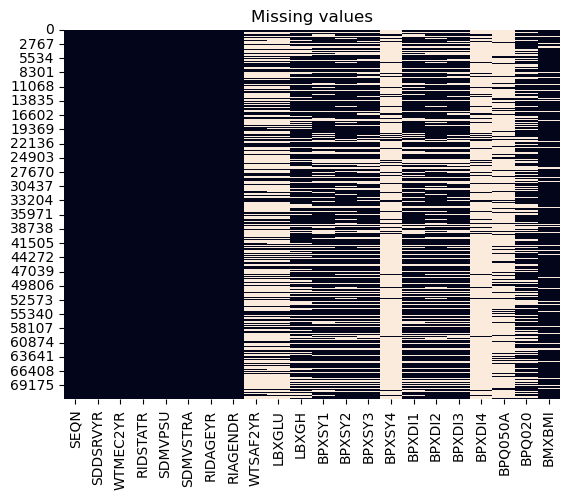

In [6]:
#vislize missing value
sns.heatmap(data.isnull(),cbar=False).set_title("Missing values")

##### MISSING DATA PREPROCESSING:<br>
DELETE the data lack BMI (as the output value, cannot fix it by filling any value type)<br>
1. using mode value to fill the missing data in categorical data type<br>
    RIDAGEYR（Age）<br>
    RIAGENDR (Gender)<br>
    RIDRETH1 (Ethnicity)<br>
2. using median value to fill the missing data in numerical data type<br>
    LBXGLU (Blood Glucose)<br>
    LBXGH (Glycated Hemoglobin)<br>
    BPXSY1–4 (Systolic Blood Pressure)<br>
    BPXDI1–4 (Diastolic Blood Pressure)<br>
    <br>
##### USELESS DATA DELETING<br>
1. SEQN: Respondent numbers<br>
2. SDDSRVYR: survey years<br>
3. SDMVPSU / SDMVSTRA: used for complex resampling<br>

In [7]:
data = data.dropna(subset=['BMXBMI'])
print("Data shape after removing missing BMI:", data.shape)#BMI is neccessary colomn and cannot random filling because it's label output


Data shape after removing missing BMI: (61983, 22)


In [8]:
# drop all useless colomns
drop_cols = [
    'SEQN',        # ID
    'SDDSRVYR',    # survey year
    'SDMVPSU',     # survey design
    'SDMVSTRA',    # survey design
    'WTSAF2YR',    # survey weight
    'BPQ050A',     # questionnaire (self-reported)
    'BPQ020',       # questionnaire (self-reported)
    'WTMEC2YR'
]
# define the categorical colomns
categorical_cols = [
    'RIAGENDR'     # gender
]
# define the numerical colomns
numerical_cols = [
    'RIDAGEYR',
    'WTMEC2YR',
    'LBXGLU', 'LBXGH',
    'BPXSY1', 'BPXSY2', 'BPXSY3', 'BPXSY4',
    'BPXDI1', 'BPXDI2', 'BPXDI3', 'BPXDI4',
    'BMXBMI'
]
# fill the missing value with median, for the numerical colomns
for col in numerical_cols:
    data[col] = data[col].fillna(data[col].median())

# fill the missing value with mode,for the categorical colomns
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
# delete unneccesary one
data = data.drop(columns=drop_cols)
print("Data preprocessing finished.")
print(data.isnull().sum())




Data preprocessing finished.
RIDSTATR    0
RIDAGEYR    0
RIAGENDR    0
LBXGLU      0
LBXGH       0
BPXSY1      0
BPXSY2      0
BPXSY3      0
BPXSY4      0
BPXDI1      0
BPXDI2      0
BPXDI3      0
BPXDI4      0
BMXBMI      0
dtype: int64


In [9]:

#missing value detection
print("length of data:", len(data))
print("number of datapoints where is at least one missing value:", len(data[data.isna().any(axis=1)]))
data.head(10)

length of data: 61983
number of datapoints where is at least one missing value: 0


,RIDSTATR,RIDAGEYR,RIAGENDR,LBXGLU,LBXGH,BPXSY1,BPXSY2,BPXSY3,BPXSY4,BPXDI1,BPXDI2,BPXDI3,BPXDI4,BMXBMI
0,2.0,2.0,2.0,96.0,5.3,116.0,116.0,114.0,116.0,68.0,68.0,68.0,68.0,14.90
1,2.0,77.0,1.0,83.7,4.7,106.0,98.0,98.0,116.0,58.0,56.0,56.0,68.0,24.90
2,2.0,10.0,2.0,96.0,5.3,110.0,104.0,112.0,116.0,60.0,64.0,62.0,68.0,17.63
4,2.0,49.0,1.0,99.9,5.5,122.0,122.0,122.0,116.0,82.0,84.0,82.0,68.0,29.10
5,2.0,19.0,2.0,96.0,5.1,116.0,116.0,112.0,116.0,64.0,60.0,80.0,68.0,22.56
6,2.0,59.0,2.0,85.6,5.8,130.0,122.0,124.0,116.0,78.0,80.0,82.0,68.0,29.39
7,2.0,13.0,1.0,84.2,5.0,116.0,106.0,100.0,96.0,68.0,44.0,48.0,56.0,15.51
8,2.0,11.0,2.0,96.0,5.3,104.0,114.0,110.0,116.0,60.0,52.0,48.0,68.0,18.48
9,2.0,43.0,1.0,89.8,5.5,152.0,142.0,142.0,116.0,98.0,94.0,96.0,68.0,30.94
10,2.0,15.0,1.0,95.9,5.2,110.0,110.0,104.0,116.0,52.0,52.0,50.0,68.0,22.00


Variable Descriptions

- **RIDSTATR**: Examination status indicating whether the participant completed the physical health examination.
- **RIDAGEYR**: Age of the participant in years.
- **RIAGENDR**: Gender of the participant.
- **LBXGLU**: Fasting blood glucose level reflecting metabolic health.
- **LBXGH**: Glycated hemoglobin (HbA1c) indicating long-term blood glucose control.
- **BPXSY1**: First systolic blood pressure measurement.
- **BPXSY2**: Second systolic blood pressure measurement.
- **BPXSY3**: Third systolic blood pressure measurement.
- **BPXSY4**: Fourth systolic blood pressure measurement.
- **BPXDI1**: First diastolic blood pressure measurement.
- **BPXDI2**: Second diastolic blood pressure measurement.
- **BPXDI3**: Third diastolic blood pressure measurement.
- **BPXDI4**: Fourth diastolic blood pressure measurement.
- **BMXBMI**: Body Mass Index (BMI) used to define the health risk label.


<b> Data Type Summary and Modeling Readiness</b>

The current dataset have only structured, tabular numerical data derived from objective health examinations and laboratory measurements. All variables are either continuous numerical values (e.g., age, blood glucose, blood pressure, BMI) or numerically encoded categorical variables (e.g., gender, examination status).

Missing values have been successully and completely handled through remove and filling with mode and median, and all survey identifiers, sampling weights, and subjective questionnaire variables have been excluded because they are not the neccessary features and will cause noise in the training. As a result, the dataset contains no missing values and no non-informative conlomns.

Because the data are clean, fully numerical, and directly related to individual health status, they are well-suited for supervised machine learning classification models such as Naive Bayes, Random Forests, and Neural Networks.


#### 1.2 Label Encoding

Health_Risk = 1 ：BMI ≥ 30（High Risk）<br>
Health_Risk = 0 ：BMI < 30（Low Risk）<br>
Body Mass Index (BMI) was encoded into a binary target variable (Health_Risk), where individuals with BMI ≥ 30 were labeled as high risk. BMI was subsequently removed from the feature set to prevent information leakage.

In [10]:
# Create target variable based on BMI
data['Health_Risk'] = (data['BMXBMI'] >= 30).astype(int)
# Check class distribution
print(data['Health_Risk'].value_counts())


Health_Risk
0    47648
1    14335
Name: count, dtype: int64


In [11]:
# Remove BMI from feature set
data = data.drop(columns=['BMXBMI'])


In [12]:
data.head(10)

,RIDSTATR,RIDAGEYR,RIAGENDR,LBXGLU,LBXGH,BPXSY1,BPXSY2,BPXSY3,BPXSY4,BPXDI1,BPXDI2,BPXDI3,BPXDI4,Health_Risk
0,2.0,2.0,2.0,96.0,5.3,116.0,116.0,114.0,116.0,68.0,68.0,68.0,68.0,0
1,2.0,77.0,1.0,83.7,4.7,106.0,98.0,98.0,116.0,58.0,56.0,56.0,68.0,0
2,2.0,10.0,2.0,96.0,5.3,110.0,104.0,112.0,116.0,60.0,64.0,62.0,68.0,0
4,2.0,49.0,1.0,99.9,5.5,122.0,122.0,122.0,116.0,82.0,84.0,82.0,68.0,0
5,2.0,19.0,2.0,96.0,5.1,116.0,116.0,112.0,116.0,64.0,60.0,80.0,68.0,0
6,2.0,59.0,2.0,85.6,5.8,130.0,122.0,124.0,116.0,78.0,80.0,82.0,68.0,0
7,2.0,13.0,1.0,84.2,5.0,116.0,106.0,100.0,96.0,68.0,44.0,48.0,56.0,0
8,2.0,11.0,2.0,96.0,5.3,104.0,114.0,110.0,116.0,60.0,52.0,48.0,68.0,0
9,2.0,43.0,1.0,89.8,5.5,152.0,142.0,142.0,116.0,98.0,94.0,96.0,68.0,1
10,2.0,15.0,1.0,95.9,5.2,110.0,110.0,104.0,116.0,52.0,52.0,50.0,68.0,0


#### 1.3 Data analysis + Feature engineer

In [13]:
# risk rate:
data["Health_Risk"].value_counts(normalize=True)

Health_Risk
0    0.768727
1    0.231273
Name: proportion, dtype: float64

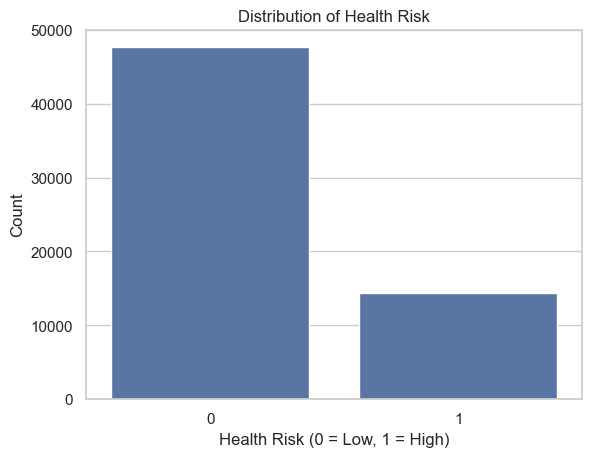

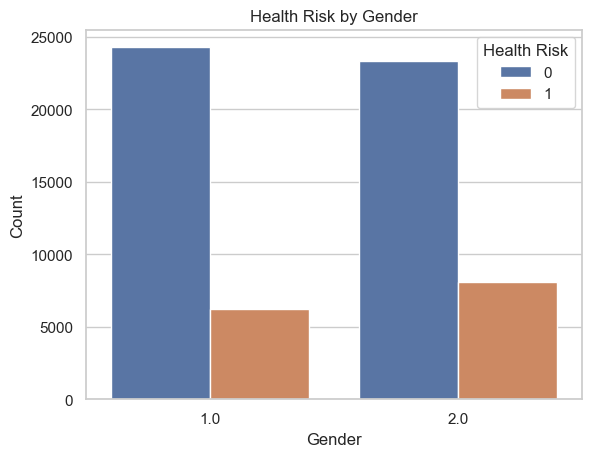

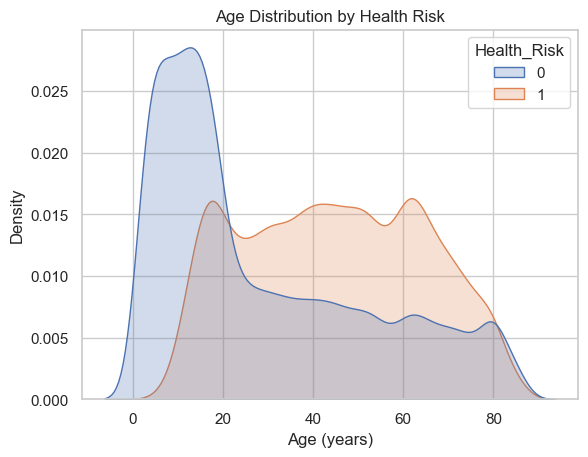

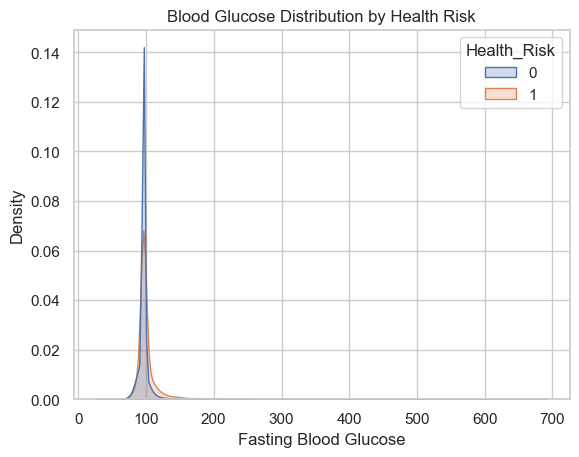

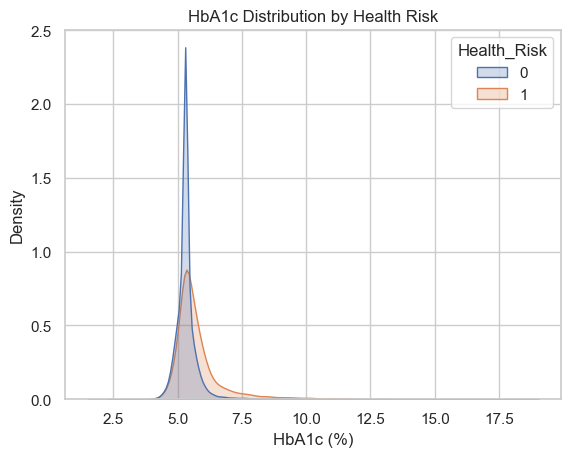

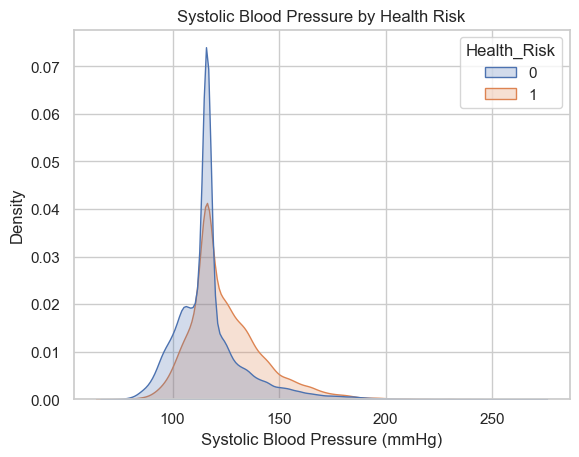

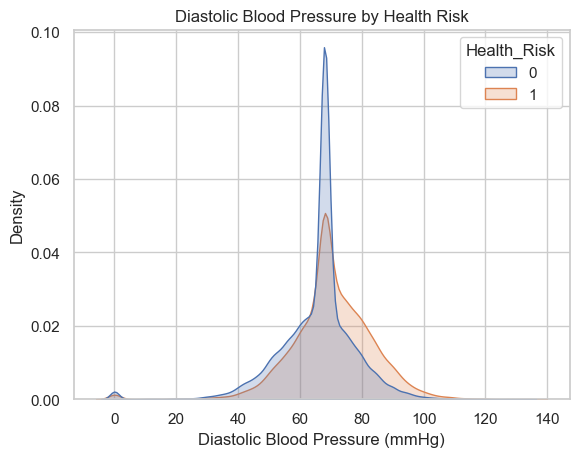

In [14]:
## These code are used for generate the distribution between labels and features, for data analysis.
sns.set(style="whitegrid")
sns.countplot(x=data['Health_Risk'])
plt.title("Distribution of Health Risk")
plt.xlabel("Health Risk (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.show()

sns.countplot(x=data['RIAGENDR'], hue=data['Health_Risk'])
plt.title("Health Risk by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Health Risk")
plt.show()

sns.kdeplot(
    data=data,
    x="RIDAGEYR",
    hue="Health_Risk",
    fill=True,
    common_norm=False
)
plt.title("Age Distribution by Health Risk")
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.show()

sns.kdeplot(
    data=data,
    x="LBXGLU",
    hue="Health_Risk",
    fill=True,
    common_norm=False
)
plt.title("Blood Glucose Distribution by Health Risk")
plt.xlabel("Fasting Blood Glucose")
plt.ylabel("Density")
plt.show()

sns.kdeplot(
    data=data,
    x="LBXGH",
    hue="Health_Risk",
    fill=True,
    common_norm=False
)
plt.title("HbA1c Distribution by Health Risk")
plt.xlabel("HbA1c (%)")
plt.ylabel("Density")
plt.show()

sns.kdeplot(
    data=data,
    x="BPXSY1",
    hue="Health_Risk",
    fill=True,
    common_norm=False
)
plt.title("Systolic Blood Pressure by Health Risk")
plt.xlabel("Systolic Blood Pressure (mmHg)")
plt.ylabel("Density")
plt.show()

sns.kdeplot(
    data=data,
    x="BPXDI1",
    hue="Health_Risk",
    fill=True,
    common_norm=False
)
plt.title("Diastolic Blood Pressure by Health Risk")
plt.xlabel("Diastolic Blood Pressure (mmHg)")
plt.ylabel("Density")
plt.show()




There is no clear linear relationship between these features and the labels. 

the low health risk label is more common than the high health risk label, which creates an imbalance in the dataset. However, after further data training, the unbalanced problem didn’t affect model performance much. That’s because this is a simple binary classification task, the large data set, and sufficient feature detail, so the models can successfully learn the relationships.

Based on these visualizations, humans can’t analyze the relationship between the features and the output label with a simple mathematical formula. These analyses emphasize the importance of using a machine learning model to understand and demonstrate the relationship between features and the output label.


##### Feature Engineering

In this study, feature engineering was conducted by augmenting the original dataset with domain-informed composite features, while retaining all raw clinical measurements.

For blood pressure, multiple systolic and diastolic readings were collected during a single examination. Instead of replacing these measurements, their averages were computed to represent overall blood pressure levels, and pulse pressure was derived as an additional cardiovascular indicator. The original measurements were preserved to allow the model to exploit both detailed and aggregated information.

For glycemic status, a binary glycemic risk indicator was constructed based on established clinical thresholds using fasting blood glucose and HbA1c. While this indicator captures overall metabolic risk in an interpretable form, the original continuous variables were retained to preserve finer-grained information.

By combining raw measurements with engineered features, the dataset provides both low-level physiological signals and higher-level risk summaries. This design allows machine learning models to learn flexible representations and assess whether aggregated features improve predictive performance beyond the original variables.


In [15]:
# 1. Blood Pressure Features
# Compute mean systolic blood pressure from repeated measurements
data['SBP_mean'] = data[['BPXSY1', 'BPXSY2', 'BPXSY3', 'BPXSY4']].mean(axis=1)
# Compute mean diastolic blood pressure from repeated measurements
data['DBP_mean'] = data[['BPXDI1', 'BPXDI2', 'BPXDI3', 'BPXDI4']].mean(axis=1)
# Pulse pressure as an additional cardiovascular risk indicator
data['Pulse_Pressure'] = data['SBP_mean'] - data['DBP_mean']

# 2. Glycemic Risk Feature
# Construct a binary glycemic risk indicator based on clinical thresholds
# Fasting glucose ≥ 100 mg/dL OR HbA1c ≥ 5.7%
data['Glycemic_Risk'] = np.where(
    (data['LBXGLU'] >= 100) | (data['LBXGH'] >= 5.7),
    1,
    0
)

# 3. Move Health_Risk to the last column
health_risk = data['Health_Risk']
data = data.drop(columns=['Health_Risk'])
data['Health_Risk'] = health_risk


print("Feature engineering finished.")
data.head(10)



Feature engineering finished.


,RIDSTATR,RIDAGEYR,RIAGENDR,LBXGLU,LBXGH,BPXSY1,BPXSY2,BPXSY3,BPXSY4,BPXDI1,BPXDI2,BPXDI3,BPXDI4,SBP_mean,DBP_mean,Pulse_Pressure,Glycemic_Risk,Health_Risk
0,2.0,2.0,2.0,96.0,5.3,116.0,116.0,114.0,116.0,68.0,68.0,68.0,68.0,115.5,68.0,47.5,0,0
1,2.0,77.0,1.0,83.7,4.7,106.0,98.0,98.0,116.0,58.0,56.0,56.0,68.0,104.5,59.5,45.0,0,0
2,2.0,10.0,2.0,96.0,5.3,110.0,104.0,112.0,116.0,60.0,64.0,62.0,68.0,110.5,63.5,47.0,0,0
4,2.0,49.0,1.0,99.9,5.5,122.0,122.0,122.0,116.0,82.0,84.0,82.0,68.0,120.5,79.0,41.5,0,0
5,2.0,19.0,2.0,96.0,5.1,116.0,116.0,112.0,116.0,64.0,60.0,80.0,68.0,115.0,68.0,47.0,0,0
6,2.0,59.0,2.0,85.6,5.8,130.0,122.0,124.0,116.0,78.0,80.0,82.0,68.0,123.0,77.0,46.0,1,0
7,2.0,13.0,1.0,84.2,5.0,116.0,106.0,100.0,96.0,68.0,44.0,48.0,56.0,104.5,54.0,50.5,0,0
8,2.0,11.0,2.0,96.0,5.3,104.0,114.0,110.0,116.0,60.0,52.0,48.0,68.0,111.0,57.0,54.0,0,0
9,2.0,43.0,1.0,89.8,5.5,152.0,142.0,142.0,116.0,98.0,94.0,96.0,68.0,138.0,89.0,49.0,0,1
10,2.0,15.0,1.0,95.9,5.2,110.0,110.0,104.0,116.0,52.0,52.0,50.0,68.0,110.0,55.5,54.5,0,0


#### 1.4 Seperate features and class

In [16]:
# Separate features (X) and label (y)
X = data.iloc[:, :-1].values   # all columns except the last one
y = data.iloc[:, -1].values   # last column: Health_Risk

In [17]:
#70-30 test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=SEED, stratify=y)

#### 1.5 Balance the training set 

In [18]:
from imblearn.over_sampling import RandomOverSampler
#the following method is used to balance the unbalance data , output result shows th difference between the original one
ros = RandomOverSampler(random_state=SEED)

X_b_train_os, y_b_train_os = ros.fit_resample(X_train, y_train)

print("Before oversampling:")
print(pd.Series(y_train).value_counts())

print("\nAfter oversampling:")
print(pd.Series(y_b_train_os).value_counts())

Before oversampling:
0    33354
1    10034
Name: count, dtype: int64

After oversampling:
1    33354
0    33354
Name: count, dtype: int64


In [19]:
X_train = X_b_train_os
y_train = y_b_train_os

Oversampling for Imbalanced Data<br>
The health risk dataset exhibits a moderate class imbalance, with the high-risk group accounting for approximately 20% of the samples. To reduce the bias toward the majority class, an oversampling strategy was applied during model training.<br>
Random oversampling was used to duplicate minority class samples in the training set, resulting in a balanced class distribution. Importantly, oversampling was applied **only to the training data**, while the test set remained unchanged to ensure fair evaluation.<br>
The balanced training data was then used to train a Support Vector Machine classifier. This approach aims to improve the model’s sensitivity to high-risk individuals by allowing the classifier to observe more minority class examples during training.<br>
It is noted that oversampling does not introduce new information and may not significantly improve overall accuracy. Instead, its primary purpose is to mitigate class bias and potentially improve recall for the minority class.


## 2.0 Training basic model

There are multiple base models were selected for this assignment

1.	Gaussian Naïve Bayes Models: GaussianNB Classification Model and BernoulliNB Classification Model.
2.	Random Forest Models: Random Forest Model with 300 trees and Random Forest Model with 500 trees. 
3.	SVM Model: Linear SVC model.
4.	Gradient Descent: SDG Regressor Model.

#### 2.1 Gaussian Naive Bayes

In [20]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train) #fit data inside the model, start to training the model
y_pred_gnb = gnb.predict(X_test)#using model to do classification to test the performance

print("GaussianNB Classification Report:")
print(classification_report(y_test, y_pred_gnb))#using classification report to get the evaluation metrics

GaussianNB Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82     14294
           1       0.43      0.49      0.46      4301

    accuracy                           0.73     18595
   macro avg       0.64      0.65      0.64     18595
weighted avg       0.75      0.73      0.74     18595



In [21]:
from sklearn.naive_bayes import BernoulliNB
# Binarize features (simple thresholding)
X_train_bin = (X_train > 0).astype(int)
X_test_bin = (X_test > 0).astype(int)

# Bernoulli Naive Bayes
bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train) #fit data inside the model, start to training the model
y_pred_bnb = bnb.predict(X_test_bin)# test the modl using test set

print("BernoulliNB Classification Report:")
print(classification_report(y_test, y_pred_bnb))

BernoulliNB Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83     14294
           1       0.43      0.47      0.45      4301

    accuracy                           0.74     18595
   macro avg       0.64      0.64      0.64     18595
weighted avg       0.74      0.74      0.74     18595



#### 2.1 Random Forest

In [22]:
rf_model = RandomForestClassifier(criterion='entropy', max_features=None, n_estimators=300, verbose=1, random_state=SEED)
#define random forest model with 300 trees
rf_model.fit(X_train, y_train)# train the model

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   12.6s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   51.0s


RandomForestClassifier(criterion='entropy', max_features=None, n_estimators=300,
                       random_state=855, verbose=1)

In [23]:
rf_predict = rf_model.predict(X_test)#test the model in the testing set
print(classification_report(y_test, rf_predict))

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.5s


              precision    recall  f1-score   support

           0       0.84      0.86      0.85     14294
           1       0.48      0.44      0.46      4301

    accuracy                           0.76     18595
   macro avg       0.66      0.65      0.65     18595
weighted avg       0.75      0.76      0.76     18595



In [24]:
rf2_model = RandomForestClassifier(criterion='entropy', max_features=None, n_estimators=500, verbose=1, random_state=SEED)

rf2_model.fit(X_train, y_train)#training the 500 trees model

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   12.6s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   50.8s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:  1.9min


RandomForestClassifier(criterion='entropy', max_features=None, n_estimators=500,
                       random_state=855, verbose=1)

In [25]:
rf_predict2 = rf2_model.predict(X_test)#test the second random forest model
print(classification_report(y_test, rf_predict2))

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.5s


              precision    recall  f1-score   support

           0       0.84      0.86      0.85     14294
           1       0.48      0.44      0.46      4301

    accuracy                           0.76     18595
   macro avg       0.66      0.65      0.65     18595
weighted avg       0.75      0.76      0.76     18595



[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    1.1s


In [26]:
# Get feature importances from the trained Random Forest model
importances = rf2_model.feature_importances_

# Exclude the target column (Health_Risk is the last column)
feature_names = data.columns[:-1]

# Create a DataFrame for feature importance
fi_data = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(fi_data)


           feature  importance
1         RIDAGEYR    0.258706
4            LBXGH    0.090195
13        SBP_mean    0.080975
15  Pulse_Pressure    0.072706
3           LBXGLU    0.071591
14        DBP_mean    0.061768
9           BPXDI1    0.058118
5           BPXSY1    0.056218
11          BPXDI3    0.053904
10          BPXDI2    0.052592
6           BPXSY2    0.052591
7           BPXSY3    0.052289
12          BPXDI4    0.012227
2         RIAGENDR    0.011509
8           BPXSY4    0.011496
16   Glycemic_Risk    0.003115
0         RIDSTATR    0.000000


<b>Random Forest Classification Results</b>

Two Random Forest classifier was trained to predict the binary **Health_Risk** outcome using demographic variables, laboratory measurements, repeated blood pressure readings, and engineered physiological features. The dataset was split into training and testing sets using a 70/30 stratified split to preserve class distribution.

<b>Feature Importance Analysis</b>

Feature importance values derived from the trained Random Forest model provide insights into which variables contribute most to health risk prediction.

- **Age (RIDAGEYR)** is the most influential feature, highlighting the strong relationship between aging and increased health risk.
- **HbA1c (LBXGH)** ranks higher than fasting blood glucose (LBXGLU), suggesting that long-term glycemic indicators are more informative than single-time glucose measurements.
- Engineered blood pressure features, including **mean systolic blood pressure (SBP_mean)**, **mean diastolic blood pressure (DBP_mean)**, and **pulse pressure**, show substantial importance. Their contributions are comparable to or greater than individual blood pressure readings, indicating that aggregating repeated measurements helps capture stable physiological patterns.
- The binary **Glycemic_Risk** feature has relatively low importance, which is expected since it is derived from existing glucose-related variables and therefore contains overlapping information.
- Gender (RIAGENDR) contributes modestly to prediction, acting as a secondary factor rather than a primary determinant of health risk.



#### 2.2 SVM

In [27]:
data.info()
#check the data again

<class 'pandas.core.frame.DataFrame'>
Index: 61983 entries, 0 to 71915
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RIDSTATR        61983 non-null  float64
 1   RIDAGEYR        61983 non-null  float64
 2   RIAGENDR        61983 non-null  float64
 3   LBXGLU          61983 non-null  float64
 4   LBXGH           61983 non-null  float64
 5   BPXSY1          61983 non-null  float64
 6   BPXSY2          61983 non-null  float64
 7   BPXSY3          61983 non-null  float64
 8   BPXSY4          61983 non-null  float64
 9   BPXDI1          61983 non-null  float64
 10  BPXDI2          61983 non-null  float64
 11  BPXDI3          61983 non-null  float64
 12  BPXDI4          61983 non-null  float64
 13  SBP_mean        61983 non-null  float64
 14  DBP_mean        61983 non-null  float64
 15  Pulse_Pressure  61983 non-null  float64
 16  Glycemic_Risk   61983 non-null  int64  
 17  Health_Risk     61983 non-null  int6

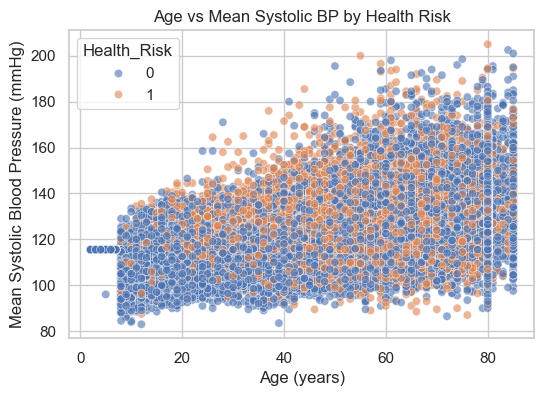

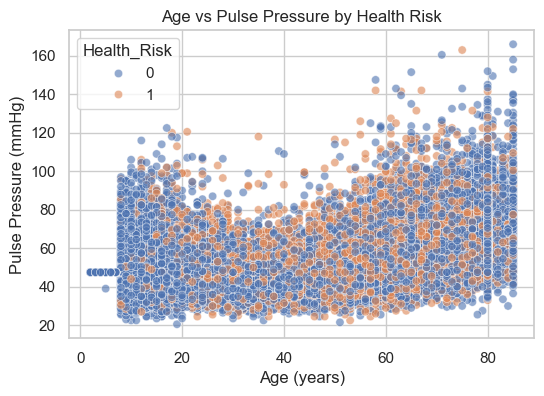

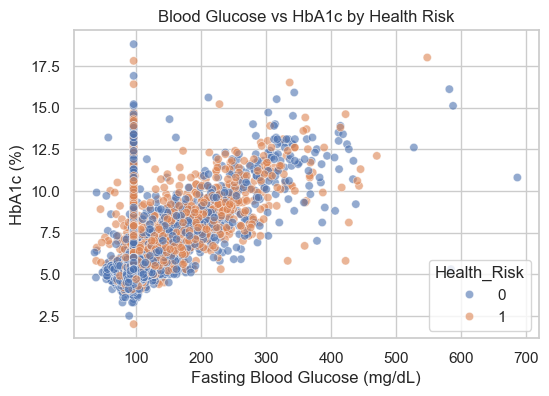

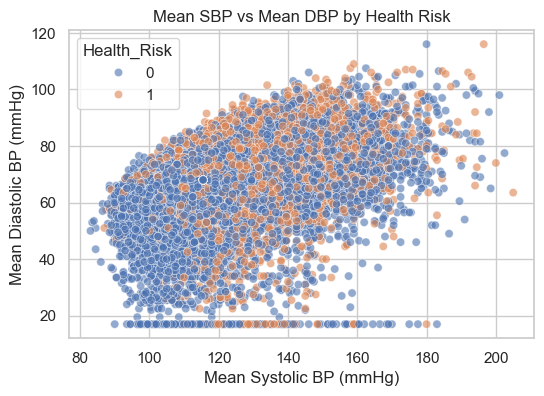

In [28]:
#The following code were used to plot the scatter distributions of labels among different important features
#  Set style
sns.set(style="whitegrid")

#Age vs Mean Systolic Blood Pressure
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=data['RIDAGEYR'],
    y=data['SBP_mean'],
    hue=data['Health_Risk'],
    alpha=0.6
)
plt.xlabel("Age (years)")
plt.ylabel("Mean Systolic Blood Pressure (mmHg)")
plt.title("Age vs Mean Systolic BP by Health Risk")
plt.show()


# Age vs Pulse Pressure
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=data['RIDAGEYR'],
    y=data['Pulse_Pressure'],
    hue=data['Health_Risk'],
    alpha=0.6
)
plt.xlabel("Age (years)")
plt.ylabel("Pulse Pressure (mmHg)")
plt.title("Age vs Pulse Pressure by Health Risk")
plt.show()


# Fasting Blood Glucose vs HbA1c
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=data['LBXGLU'],
    y=data['LBXGH'],
    hue=data['Health_Risk'],
    alpha=0.6
)
plt.xlabel("Fasting Blood Glucose (mg/dL)")
plt.ylabel("HbA1c (%)")
plt.title("Blood Glucose vs HbA1c by Health Risk")
plt.show()


# Mean Systolic BP vs Mean Diastolic BP
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=data['SBP_mean'],
    y=data['DBP_mean'],
    hue=data['Health_Risk'],
    alpha=0.6
)
plt.xlabel("Mean Systolic BP (mmHg)")
plt.ylabel("Mean Diastolic BP (mmHg)")
plt.title("Mean SBP vs Mean DBP by Health Risk")
plt.show()


Scatter Plot Observations and Model Implications

From the scatter plots, several general patterns can be observed.  
Age shows a clear positive relationship with mean systolic blood pressure and pulse pressure, indicating that cardiovascular indicators tend to increase with age. Similarly, fasting blood glucose and HbA1c exhibit a positive correlation, which is consistent with clinical knowledge about glucose metabolism. Mean systolic and diastolic blood pressure are also strongly correlated, reflecting overall blood pressure level rather than distinct risk groups.

However, across all plots, samples with `Health_Risk = 0` and `Health_Risk = 1` are highly overlapped. There is no clear linear boundary that separates the two classes in any two-dimensional feature space. This suggests that health risk cannot be determined by a single feature or a simple combination of two features.

From a modeling perspective, this data structure is not ideal for SVM with a linear kernel, as the classes are not linearly separable. Even with a non-linear kernel, SVM may struggle because the class separation relies on complex interactions among multiple variables rather than a clear margin in low-dimensional space. In contrast, tree-based models such as Random Forest are better suited to capture these non-linear and multi-feature interactions.


In [29]:
svm_model = LinearSVC()#define the svm model
svm_model.fit(X_train, y_train)#training the model

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC()

In [30]:
svm_predict = svm_model.predict(X_test)#test the model
print(classification_report(y_test,svm_predict))#show the test results

              precision    recall  f1-score   support

           0       0.96      0.24      0.38     14294
           1       0.28      0.97      0.43      4301

    accuracy                           0.41     18595
   macro avg       0.62      0.60      0.41     18595
weighted avg       0.80      0.41      0.39     18595



In [31]:
#using percentage to clearly show the result, condcut the confusion matrix
percentage = svm_model.score(X_test, y_test)
res=confusion_matrix(y_test, svm_predict)
print("Confusion Matrix")
print(res)
print(f"Test Set:{len(X_test)}")
print(f"Accuracy = {percentage*100}%")

Confusion Matrix
[[ 3413 10881]
 [  145  4156]]
Test Set:18595
Accuracy = 40.70449045442323%


#### 2.4 Gradient Descent

In [32]:
from sklearn.linear_model import SGDRegressor

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61983 entries, 0 to 71915
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RIDSTATR        61983 non-null  float64
 1   RIDAGEYR        61983 non-null  float64
 2   RIAGENDR        61983 non-null  float64
 3   LBXGLU          61983 non-null  float64
 4   LBXGH           61983 non-null  float64
 5   BPXSY1          61983 non-null  float64
 6   BPXSY2          61983 non-null  float64
 7   BPXSY3          61983 non-null  float64
 8   BPXSY4          61983 non-null  float64
 9   BPXDI1          61983 non-null  float64
 10  BPXDI2          61983 non-null  float64
 11  BPXDI3          61983 non-null  float64
 12  BPXDI4          61983 non-null  float64
 13  SBP_mean        61983 non-null  float64
 14  DBP_mean        61983 non-null  float64
 15  Pulse_Pressure  61983 non-null  float64
 16  Glycemic_Risk   61983 non-null  int64  
 17  Health_Risk     61983 non-null  int6

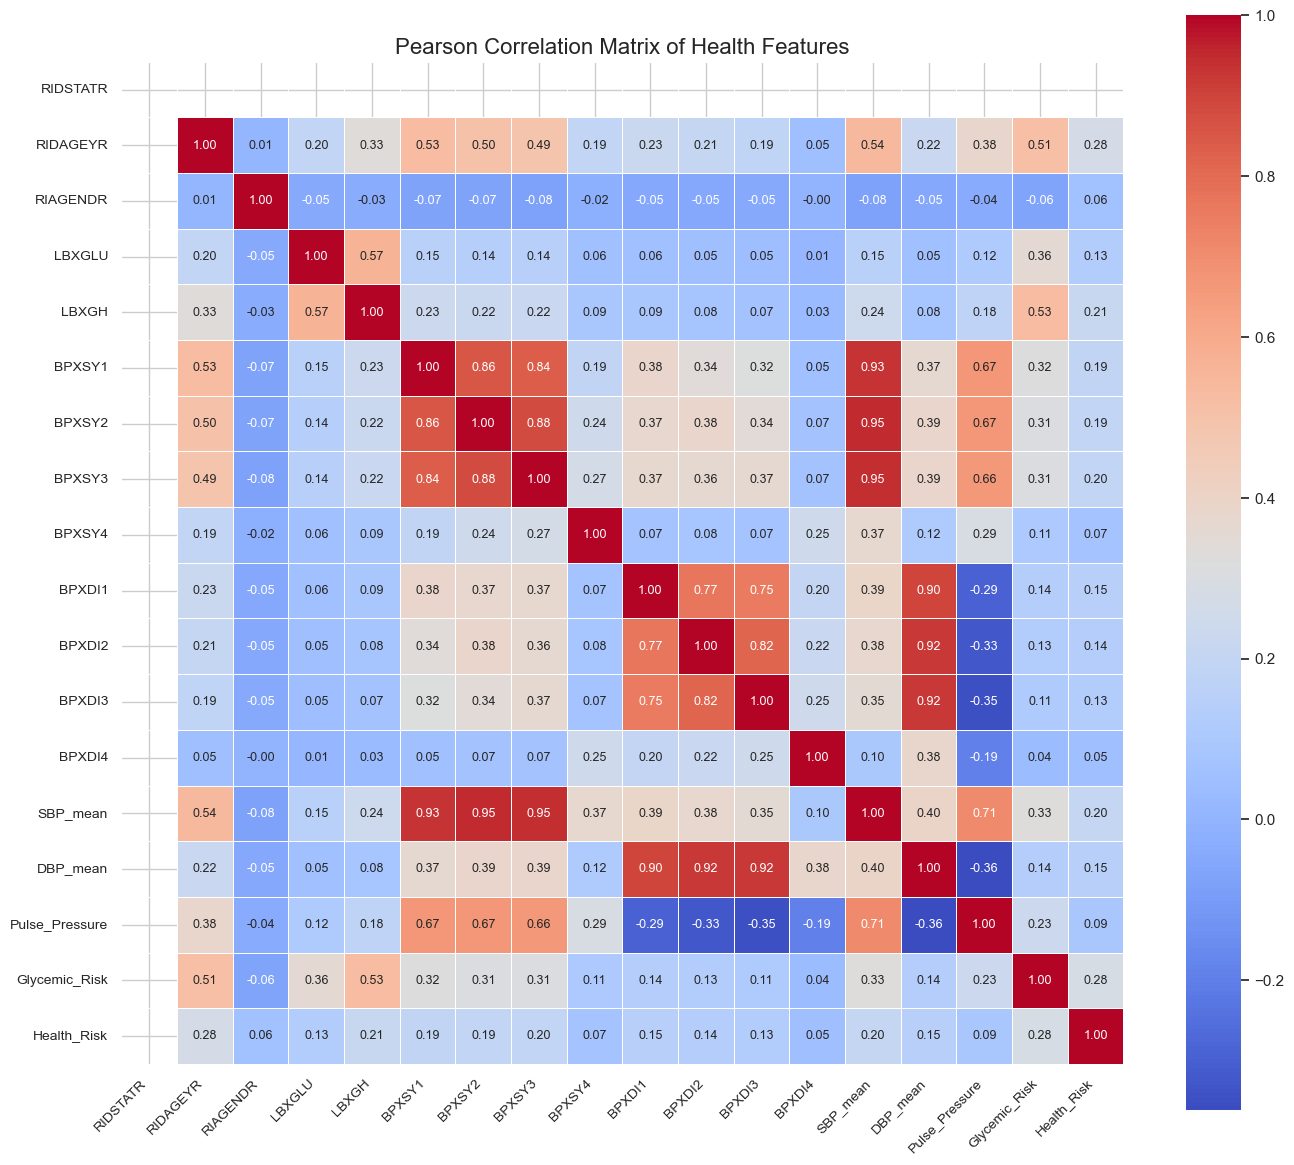

In [34]:
#plot the pearson correlation matrix using heatmap.
corr = data.corr(method="pearson")
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar=True,
    annot_kws={"size": 9} 
)

plt.title("Pearson Correlation Matrix of Health Features", fontsize=16)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [35]:
from sklearn import preprocessing
X_train_std = preprocessing.StandardScaler().fit_transform(X_train)#standardize the dataset
X_test_std = preprocessing.StandardScaler().fit_transform(X_test)#standardize the dataset
y_train


array([1, 0, 0, ..., 1, 1, 1])

In [36]:
linsgd = SGDRegressor(random_state=SEED, max_iter=1000)#define the gradient descent model
linsgd.fit(X_train_std, y_train)#training the model

SGDRegressor(random_state=855)

In [37]:
#the main target of these code is to show the performance metrics of  the gradient descent model
y_pred_continuous = linsgd.predict(X_test_std)#test the model
y_pred = (y_pred_continuous >= 0.5).astype(int)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Prediction
y_pred_cont = linsgd.predict(X_test_std)
y_pred = (y_pred_cont >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("SGD (Gradient Descent Linear Model)")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


SGD (Gradient Descent Linear Model)
Accuracy : 0.6851304114009142
Precision: 0.3952547856565112
Recall   : 0.6817019297837712
F1-score : 0.5003839918081747

Confusion Matrix:
[[9808 4486]
 [1369 2932]]


## 3.0 Advanced Model(MLP)

#### 3.1 Base MLP

In [38]:
# Separate features (X) and label (y) #redo to make sure code maintainance
X = data.iloc[:, :-1].values   # all columns except the last one
y = data.iloc[:, -1].values   # last column: Health_Risk

In [39]:
#70-30 test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=SEED, stratify=y)

In [40]:
ros = RandomOverSampler(random_state=SEED)#redo the data balance, advanced machine learning model shows a significantly bad performance on unbalanced dataset.

X_b_train_os, y_b_train_os = ros.fit_resample(X_train, y_train)
X_train = X_b_train_os
y_train = y_b_train_os

In [41]:
from tensorflow import keras
from tensorflow.keras import layers
#define the architecture of the mlp model
mlp_model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),#first hidden layer
    layers.Dropout(0.3), 
    layers.Dense(16, activation="relu"),#second hidden layer
    layers.Dropout(0.3),        
    layers.Dense(1, activation="sigmoid") #output layer
])


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
mlp_model.compile (optimizer="adam", loss="binary_crossentropy", metrics =["accuracy"])#define the loss function and the optimizer

Since the prediction task is a binary classification problem with a sigmoid output layer, binary cross-entropy is selected as the loss function. The Adam optimizer is adopted as a robust default choice that performs well across a wide range of problems and requires minimal hyperparameter tuning.

In [43]:
early_stop = keras.callbacks.EarlyStopping(#define the early stop function
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = mlp_model.fit(#savinf the traning loss and accuracy for future loss score an accuracy visualization
    X_train,
    y_train,
    epochs=50,                 
    batch_size=30,            
    validation_split=0.2,   
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/50
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 2s 540us/step - accuracy: 0.5715 - loss: 3.0188 - val_accuracy: 0.0854 - val_loss: 0.8599
Epoch 2/50
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 1s 504us/step - accuracy: 0.6308 - loss: 0.6185 - val_accuracy: 0.0336 - val_loss: 0.8618
Epoch 3/50
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 1s 497us/step - accuracy: 0.6414 - loss: 0.5987 - val_accuracy: 0.1850 - val_loss: 0.8156
Epoch 4/50
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step - accuracy: 0.6394 - loss: 0.5879 - val_accuracy: 0.0803 - val_loss: 0.7880
Epoch 5/50
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 1s 497us/step - accuracy: 0.6419 - loss: 0.5787 - val_accuracy: 0.1536 - val_loss: 0.8469
Epoch 6/50
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step - accuracy: 0.6427 - loss: 0.5765 - val_accuracy: 0.0812 - val_loss: 0.8654
Epoch 7/50
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 1s 499us/step - accuracy: 0.6427 - loss: 0.5761 - val_accuracy: 0.4972 - val_loss: 0.7971


In [44]:
history_dict = history.history
history_dict.keys()#shows the key inside the saving dictionary

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

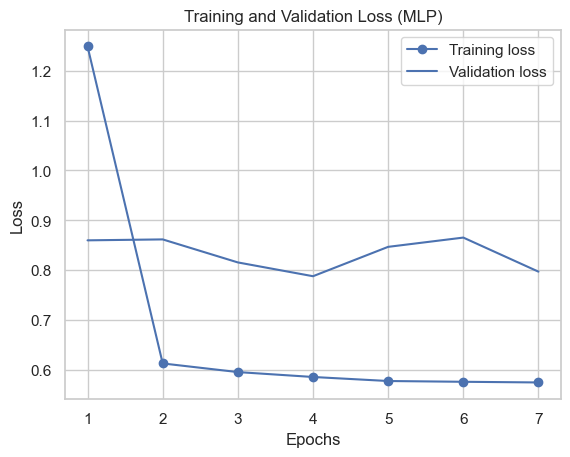

In [45]:
#plot the training and validation loss plot to show overall model performance
history_dict = history.history
loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (MLP)")
plt.legend()
plt.show()


Interpretation of Training Epochs

The MLP model converges very quickly on this dataset. As shown in the loss curves, both training
and validation loss decrease sharply within the first few epochs. After around **5–7 epochs**,
the validation loss reaches a stable plateau and no longer shows meaningful improvement.

This indicates that the model has already learned the essential patterns in the data, and
additional training epochs would not improve generalization performance. Training beyond this
point may instead increase the risk of overfitting.

Therefore, stopping training at **7 epochs** is sufficient and appropriate for this task, and
the model can be considered successfully trained.


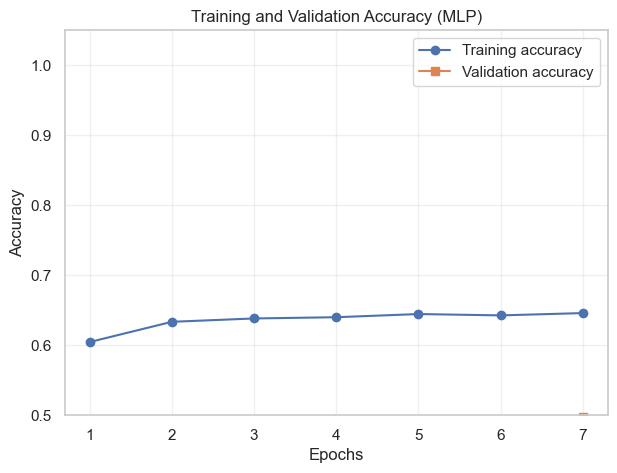

In [46]:
#visualize the accuracy plot
history_dict = history.history

acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, acc, "o-", label="Training accuracy")
plt.plot(epochs, val_acc, "s-", label="Validation accuracy")

plt.title("Training and Validation Accuracy (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.ylim(0.5, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [47]:
mlp_result = mlp_model.evaluate(X_test, y_test) #test the model
mlp_result

582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - accuracy: 0.7647 - loss: 0.5275


[0.5237764716148376, 0.7680559158325195]

In [48]:

mlp_prob = mlp_model.predict(X_test).ravel()#saving the test result

mlp_pred = (mlp_prob >= 0.5).astype(int)#using threhold to change the probability value into binary value


582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 231us/step


In [49]:
#these code here is created to show the performance metrics of MLP model
acc = accuracy_score(y_test, mlp_pred)
prec = precision_score(y_test, mlp_pred)
rec = recall_score(y_test, mlp_pred)
f1 = f1_score(y_test, mlp_pred)

print("Baseline MLP Results")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, mlp_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, mlp_pred))


Baseline MLP Results
Accuracy : 0.7681
Precision: 0.4914
Recall   : 0.0797
F1-score : 0.1372

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     14294
           1       0.49      0.08      0.14      4301

    accuracy                           0.77     18595
   macro avg       0.64      0.53      0.50     18595
weighted avg       0.71      0.77      0.70     18595


Confusion Matrix:
[[13939   355]
 [ 3958   343]]


#### 3.2 Advanced MLP

Another MLP architecture design. 

This MLP model was implemented in more detail, with more specific layers and additional functions.
It can capture more detailed information and relationships between features.


In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [51]:
#define second mlp model using same opitimizer and loss function, the inner architecture is different
mlp_model2 = Sequential([
    Dense(128, input_shape=(X_train_std.shape[1],)),#hidden layer 1
    BatchNormalization(),#an normalization layer for better undertanding
    tf.keras.layers.ReLU(),
    Dropout(0.3),

    Dense(64),#hidden layer two
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])
mlp_model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
early_stop = EarlyStopping(#define early stop
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

class_weight = {# using class_weight to avoid the inbalance problem
    0: 1.0,
    1: 3.3
}


history = mlp_model2.fit(#saving the performance metrcs
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)


Epoch 1/100
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 2s 807us/step - accuracy: 0.6271 - loss: 1.0485 - precision: 0.5009 - recall: 0.8633 - val_accuracy: 0.9635 - val_loss: 0.3157 - val_precision: 1.0000 - val_recall: 0.9635
Epoch 2/100
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - accuracy: 0.6251 - loss: 0.9652 - precision: 0.4992 - recall: 0.9228 - val_accuracy: 0.9574 - val_loss: 0.3261 - val_precision: 1.0000 - val_recall: 0.9574
Epoch 3/100
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 1s 734us/step - accuracy: 0.6275 - loss: 0.9507 - precision: 0.5012 - recall: 0.9276 - val_accuracy: 0.8803 - val_loss: 0.4688 - val_precision: 1.0000 - val_recall: 0.8803
Epoch 4/100
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - accuracy: 0.6275 - loss: 0.9393 - precision: 0.5016 - recall: 0.9292 - val_accuracy: 0.9322 - val_loss: 0.4244 - val_precision: 1.0000 - val_recall: 0.9322
Epoch 5/100
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 1s 806us/step - accuracy: 0.6204 - loss: 0.9430 - precision: 0.4972 - recall: 0.9387 - val_accura

In [53]:
#show the performance metrics of the second mlp model
y_prob = mlp_model2.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Improved MLP Results")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Recall: {recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step
Improved MLP Results
Accuracy: 0.4867
F1-score: 0.4676
Recall: 0.9747

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.34      0.50     14294
           1       0.31      0.97      0.47      4301

    accuracy                           0.49     18595
   macro avg       0.64      0.66      0.49     18595
weighted avg       0.82      0.49      0.50     18595


Confusion Matrix:
[[4858 9436]
 [ 109 4192]]


#### 3.3 Advanced Model (Tabnet)

In [54]:
!pip install pytorch-tabnet


  Using cached pytorch_tabnet-4.1.0-py3-none-any.whl.metadata (15 kB)
Using cached pytorch_tabnet-4.1.0-py3-none-any.whl (44 kB)

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [55]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

import torch
from pytorch_tabnet.tab_model import TabNetClassifier
#try tabnet model

In [56]:
tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.02),
    mask_type="entmax",  # attention-like feature selection
    verbose=10
)
#define the tabnet model

/opt/anaconda3/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [57]:
tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=128,
    drop_last=False
)
#training the tabnet model with selected hyperparameters

epoch 0  | loss: 0.59383 | val_accuracy: 0.43743 |  0:00:03s
epoch 10 | loss: 0.53798 | val_accuracy: 0.64722 |  0:00:36s
epoch 20 | loss: 0.52791 | val_accuracy: 0.69814 |  0:01:12s

Early stopping occurred at epoch 24 with best_epoch = 4 and best_val_accuracy = 0.70013


/opt/anaconda3/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [58]:
y_pred = tabnet.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="binary")
recall = recall_score(y_test, y_pred, average="binary")

print("TabNet Results")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Recall: {recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
#shows the final performance metrics scores of the tabnet model

TabNet Results
Accuracy: 0.7001
F1-score: 0.5275
Recall: 0.7238

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.69      0.78     14294
           1       0.42      0.72      0.53      4301

    accuracy                           0.70     18595
   macro avg       0.65      0.71      0.65     18595
weighted avg       0.78      0.70      0.72     18595


Confusion Matrix:
[[9906 4388]
 [1188 3113]]


## 4.0 Model Evaluation

#### 4.1 Paired T-test

In [59]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import ttest_rel

In [60]:
models = {
    "GNB": gnb,
    "BNB":bnb,
    "SVM": svm_model,
    "GradientDscent ":linsgd,
    "RF1": rf_model,
    "RF2": rf2_model,
    "MLP1": mlp_model,
    "MLP2": mlp_model2,
    "Tabnet": tabnet
}
#saving all model inside one dictionary for further cross validation loops

In [61]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#repeat the model training in 5 folds, every times record the target value to conduct the t-test and whisker plot 
X_np = X.values if hasattr(X, "values") else X
y_np = y.values if hasattr(y, "values") else y

results = {name: [] for name in models.keys()}


In [ ]:
for fold, (train_idx, test_idx) in enumerate(kf.split(X_np, y_np), 1):
    X_train, X_test = X_np[train_idx], X_np[test_idx]
    y_train, y_test = y_np[train_idx], y_np[test_idx]

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_raw = model.predict(X_test)
        y_raw = np.asarray(y_raw).reshape(-1)

        # binary prediction
        if not np.issubdtype(y_raw.dtype, np.integer):
            y_pred = (y_raw >= 0.5).astype(int)
        else:
            y_pred = y_raw.astype(int)

        # === F1 score（关键改动）===
        f1 = f1_score(y_test, y_pred, average="binary")
        results[name].append(f1)

    print(f"Fold {fold} done")



/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    9.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   37.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    9.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   37.5s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:  1.4min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.3s


 121/1550 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.7552 - loss: 0.5006

[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.7s


1550/1550 ━━━━━━━━━━━━━━━━━━━━ 1s 408us/step - accuracy: 0.7673 - loss: 0.4902
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 217us/step
1550/1550 ━━━━━━━━━━━━━━━━━━━━ 1s 629us/step - accuracy: 0.7415 - loss: 0.4893 - precision: 0.4273 - recall: 0.2386
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step


/opt/anaconda3/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.5334  |  0:00:01s
epoch 10 | loss: 0.44189 |  0:00:14s
epoch 20 | loss: 0.43421 |  0:00:27s


In [ ]:
max_len = max(len(v) for v in results.values())

for name, scores in results.items():
    if len(scores) < max_len:
        results[name] = scores + [np.nan] * (max_len - len(scores))

results_df = pd.DataFrame(results)
results_df

#making sure the length of each result is same for furthur visualization

In [ ]:
model_names = list(results.keys())

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        a, b = model_names[i], model_names[j]

        x = np.array(results[a])
        y_ = np.array(results[b])

        # remove NaN
        mask = ~np.isnan(x) & ~np.isnan(y_)
        x, y_ = x[mask], y_[mask]

        # paired t-test
        if len(x) < 2:
            print(f"{a} vs {b}: skipped")
            continue

        t, p = ttest_rel(x, y_)
        print(f"{a} vs {b}: t={t:.4f}, p={p:.4f}")
#do paired t-test and get the results

In [ ]:
#using matrix to visualize the results
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

model_names = list(results_df.columns)
n = len(model_names)

p_matrix = pd.DataFrame(np.nan, index=model_names, columns=model_names)

for i in range(n):
    for j in range(n):
        if i == j:
            continue
        x = results_df.iloc[:, i].values
        y = results_df.iloc[:, j].values

        mask = ~np.isnan(x) & ~np.isnan(y)
        x, y = x[mask], y[mask]

        if len(x) >= 2:
            _, p = ttest_rel(x, y)
            p_matrix.iloc[i, j] = p

plt.figure(figsize=(11, 9))

im = plt.imshow(
    p_matrix.values,
    cmap="viridis",
    vmin=0.0,
    vmax=0.10
)


plt.xticks(range(n), model_names, rotation=45, ha="right")
plt.yticks(range(n), model_names)

plt.colorbar(im, label="p-value")
plt.title("Paired t-test p-value Matrix")

for i in range(n):
    for j in range(n):
        if i != j and not np.isnan(p_matrix.iloc[i, j]):
            plt.text(
                j, i,
                f"{p_matrix.iloc[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

plt.tight_layout()
plt.show()



The exceptionally high recall score of Improved MLP indicates that it cannot
distinguish between the two labels. GaussianNB and BernoulliNB also show F1 scores that are
too low. Even their recall is low, and their performance is too low. Two random forest models
show the highest accuracy and a stable classification. However, their recall is relatively low,
making their mistakes more harmful to classification. GNB and Random Forest perform best among the 9 models, and TabNet
also shows good performance. To confirm that, paired t-tests were conducteLinear SVC and Gradient Descent models
achieve relatively low accuracy, mainly because they are linear classification models. 

The final
comparison between Baseline MLP and TabNet shows that TabNet achieves relatively high
accuracy and the highest F1 score, making it the best model for this classification task among
these 9 models. However, such a comparison still needs support from a statistical test to find the
significantly best model.

#### 4.2 Box and Whisker Plots

This section used Box and Whisker Plot to show the distribution of the F1 score of these 9 models

In [ ]:
plt.figure(figsize=(12, 6))

data = [results_df[col].dropna().values for col in results_df.columns]

plt.boxplot(data, labels=results_df.columns, showfliers=True)

plt.ylabel("F1-score")
plt.title("5-Fold Cross-Validation F1-score Comparison Across Models")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
y_min = results_df.min().min()
y_max = results_df.max().max()
plt.ylim(y_min - 0.02, y_max + 0.02)

plt.tight_layout()
plt.show()


GNB and Random Forest perform best among the 9 models, and TabNet
also shows good performance. To confirm that, paired t-tests were conducte

## 5.0 Conclusion
From a data perspective, effective data preprocessing and feature engineering are key to
improving model performance. By combining multiple blood pressure measurements,
introducing pulse pressure as a new indicator, and creating an elevated glycemic risk indicator,
the dataset provides both the fundamental and aggregated indicators simultaneously. These
feature engineering designs ensure the model can capture medical patterns and retain detailed
physiological information. The future visualisation and analysis indicate that there is now a clear
linear relationship between each feature and the labels, underscoring the need to use a machine
learning method to build the model.

After a systematic comparison, TabNet Classifier and Random Forest both show the highest
stability and performance on this task. They achieve the highest F1-score while maintaining high
accuracy and recall.

In conclusion, this report shows that combining field-knowledge-driven feature engineering with
reasonable model selection can significantly improve performance in health risk classification.
This report emphasises models such as TabNet, which focus on structured datasets,
demonstrating immense value in solving medical and public health problems.